# NLP on np20ng — Nepali News: Text Preprocessing & Tokenization

This notebook is based on Jurafsky & Martin, *Speech and Language Processing*, Chapter 2) but applies every
step to **our own Nepali dataset, np20ng** (200K+ Nepali news documents in the
Devanagari script).

**Pipeline (and why each step is different for Nepali):**
1. **Diagnostics** — *measure* the noise instead of guessing (structure, length,
   regex noise patterns, characters, vocabulary, Zipf's law).
2. **Cleaning pipeline** — a reproducible, ordered cleaner adapted for Devanagari
   (mojibake, HTML, URLs, emoji, zero-width joiners, Unicode NFC normalization).
3. **Tokenization** — Unicode/UTF-8 for Devanagari, regex tokenization, rule-based
   tokenization, and a **BPE tokenizer trained on Nepali**.

Everything runs on a **random sample** (one `SAMPLE_SIZE` knob) so it is fast.
We deliberately stop at BPE — modelling/classification is out of scope here, exactly
like the reference notebook.


## About this project (read this first)

**What is the dataset?**  `np20ng` = **"Nepali 20 News Groups"** — a collection of
**231,216 Nepali news articles** collected from Nepali news websites (Gorkhapatra,
Nagarik, Nepalkhabar, Aarthiknews, and more). Every article has 4 fields:

| Column | Meaning |
|---|---|
| **source** | which news website it came from |
| **category** | the topic — 20 in total (Politics, Sports, Health, Economy, Entertainment, …) |
| **heading** | the article's title |
| **content** | the full article text — *this is what we mainly work on* |

**Our main aim:** take **raw, messy Nepali news text** and turn it into clean **tokens**
(the small units a computer uses for language tasks). We do it in three stages:

1. **Diagnose** — measure the mess with numbers (don't guess).
2. **Clean** — fix the problems with an ordered, repeatable pipeline.
3. **Tokenize** — split the text into units, ending with a **BPE tokenizer trained on Nepali**.

**Why do this for Nepali specially?**  Almost all NLP tools are built for English.
Nepali is different: it is written in **Devanagari script**, has **no capital/small letters**,
ends sentences with **`।` (danda)** instead of a full stop `.`, and often packs many
meanings into a **single word**. So we cannot blindly reuse English tools — this notebook
shows exactly which Nepali-specific changes are needed.

## 0. Setup

We load a Devanagari-capable font so Nepali text renders in matplotlib plots
instead of showing empty boxes (▯).

### Setup: import tools + load a Nepali font

**What it does:** imports the Python libraries we need (`pandas` for tables,
`matplotlib` for charts, `re` for regular expressions, `unicodedata` for Unicode),
then searches the computer for a font that can draw Devanagari letters.

**Why we do it:** matplotlib's default font **cannot draw Nepali letters** — it shows
empty boxes `▯` in charts. So we load a Nepali-capable font (like *Nirmala UI*) first.

**Output:** `Devanagari font for plots: Nirmala UI` means a good font was found and our
Nepali chart labels will display correctly.

In [1]:
# Imports + Devanagari-capable font for matplotlib
import os, re, unicodedata
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager

DEV_FONT = None
for cand in [r"C:\Windows\Fonts\Nirmala.ttc", r"C:\Windows\Fonts\mangal.ttf",
             r"C:\Windows\Fonts\NotoSansDevanagari-Regular.ttf"]:
    if os.path.exists(cand):
        try:
            font_manager.fontManager.addfont(cand)
            DEV_FONT = font_manager.FontProperties(fname=cand).get_name()
            break
        except Exception:
            pass
if DEV_FONT:
    plt.rcParams["font.family"] = DEV_FONT
    print("Devanagari font for plots:", DEV_FONT)
else:
    print("WARNING: no Devanagari font found; Nepali labels in plots may show as boxes.")
plt.rcParams["axes.unicode_minus"] = False

Devanagari font for plots: Nirmala UI


## 1. Data Loading

The reference used a `text` column; our text lives in `content`, so we rename it to
`text` and keep the rest of the notebook identical in spirit. We take a fixed random
**sample** — set `SAMPLE_SIZE = None` to run on all 231K rows.

### Step 1 — Load the data (and take a small sample)

**What it does:** reads the CSV file into a table, then keeps a **random sample of 8,000
articles** instead of all 231,216. `RANDOM_STATE = 42` makes the "random" pick the *same*
every time (so results are reproducible). We rename `content` → `text` because the rest of
the notebook expects a column called `text`.

**Why sample?** 231K rows are slow to process live in class; 8,000 is more than enough to
demonstrate every step and runs in a few seconds. (Set `SAMPLE_SIZE = None` to use all rows.)

**Output:** full dataset `(231216, 4)`, working sample `(8000, 4)`, and a 5-row preview
showing real Nepali headings and article text.

In [2]:
DATA_PATH    = r"D:\nepaliNLP\dataset\np20ng.csv"
SAMPLE_SIZE  = 8000   # <-- single knob. Set to None for the full ~231K rows.
RANDOM_STATE = 42

df_full = pd.read_csv(DATA_PATH, usecols=["source", "category", "heading", "content"])
print("Full dataset:", df_full.shape)

if SAMPLE_SIZE:
    df = df_full.sample(n=SAMPLE_SIZE, random_state=RANDOM_STATE).reset_index(drop=True)
else:
    df = df_full.copy()
df = df.rename(columns={"content": "text"})
del df_full
print("Working sample:", df.shape)
df.head()

Full dataset: (231216, 4)


Working sample: (8000, 4)


,source,category,heading,text
0,Gorkhapatra,Health,२४ घण्टामा कोरोनाले बिपी प्रतिष्ठानमा तीन जनाक...,"धरान, माघ ७ गते । धरानस्थित बिपी कोइराला स्वास..."
1,Nagarik,Technology,स्मार्टफोनपछि ल्यापटप र डेस्कटपमापनि फेसबुक ला...,क्यालिर्फोनिया–विश्वप्रसिद्ध सामाजिक संजाल फे...
2,Nepalkhabar,Economy,आईएमई पे एपको टप–अपमा नयाँ क्यासब्याक अफर अद्य...,आईएमई पेले मोबाइल रिचार्जमा नयाँ अफर अद्यावधिक...
3,Aarthiknews,Health,भारतमा कोरोना संक्रमणबाट मर्नेको संख्या २१ सय ...,भारत । भारतमा कोरोना संक्रमणका कारण मर्नेको सं...
4,Nepalkhabar,Entertainment,आमिरको ‘लालसिंह चड्डा’मा शाहरुखको इन्ट्री!,बलिउडका सुपरस्टार अभिनेता आमिर खानको महत्वाकां...


## 2. Diagnostics — turn "I think it's messy" into measurable evidence

Cleaning is not guesswork. Before touching the text we **measure** what is actually
in it. Every check below answers one concrete question.

### Step 2 — Diagnostics: a health check of the data

**What it does:** counts the obvious problems — **null** (missing) text, **empty/blank**
rows, and **exact duplicate** articles — and lists how many categories there are.

**Why we do it:** we fix problems based on **evidence, not guesses**. Knowing there are
2 null, 2 empty, and 1 duplicate row tells us exactly what to drop later.

**Output:** 2 null rows, 2 empty rows, 1 duplicate, and **20 categories** (Politics,
Society and Sports are the largest).

In [3]:
# Structural inspection: shape, dtypes, missing/empty, duplicates
print("Shape:", df.shape)
print("\nDtypes:\n", df.dtypes)

n_null  = int(df["text"].isnull().sum())
n_empty = int((df["text"].fillna("").str.strip() == "").sum())
n_dup   = int(df["text"].duplicated().sum())
print(f"\nNull text rows:              {n_null}")
print(f"Empty/whitespace-only rows:  {n_empty}")
print(f"Exact duplicate texts:       {n_dup}")

print("\nCategories:", df["category"].nunique())
print(df["category"].value_counts().head(10))

Shape: (8000, 4)

Dtypes:
 source      object
category    object
heading     object
text        object
dtype: object

Null text rows:              2
Empty/whitespace-only rows:  2
Exact duplicate texts:       1

Categories: 20
category
Politics         1090
Society           956
Sports            832
Economy           797
Entertainment     735
World             622
Business          422
Bank              376
Health            328
Crime             295
Name: count, dtype: int64


### How long are the articles?

**What it does:** measures each article's length in **characters** and in **words**, then
draws two histograms showing the spread. It also prints the 5 shortest articles.

**Why we do it:** very **short** documents (1–2 words) are often junk or stray headings;
very **long** ones can be outliers. Knowing the length distribution helps us spot these.

**Output:** most articles cluster around a typical length with a **long right tail** (a few
very long articles), and the shortest documents are printed so we can eyeball them.

           char_len     word_len
count   8000.000000  8000.000000
mean    1761.431250   271.007625
std     1889.164969   295.045977
min        0.000000     0.000000
25%      741.000000   114.000000
50%     1146.000000   177.000000
75%     2008.250000   306.000000
max    30091.000000  4665.000000


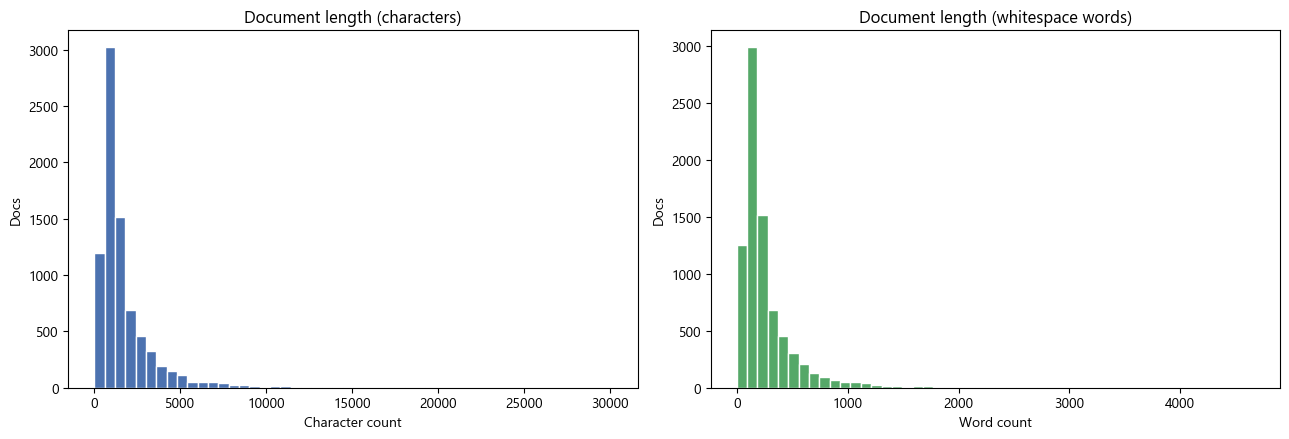


Shortest 5 docs by word count:
  [  0 w] (Tourism) nan
  [  0 w] (Lifestyle) nan
  [  1 w] (Tourism) काठमाडौँ
  [  1 w] (Tourism) कपिलवस्तु
  [  9 w] (Tourism) लुम्बिनी । बुद्ध जन्मस्थल लुम्बिनी घुम्न आएका आन्तरिक पर्यटक


In [4]:
# Length distribution: find very short / very long documents
df["char_len"] = df["text"].fillna("").str.len()
df["word_len"] = df["text"].fillna("").str.split().apply(len)
print(df[["char_len", "word_len"]].describe())

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].hist(df["char_len"], bins=50, color="#4C72B0", edgecolor="white")
axes[0].set_title("Document length (characters)")
axes[0].set_xlabel("Character count"); axes[0].set_ylabel("Docs")
axes[1].hist(df["word_len"], bins=50, color="#55A868", edgecolor="white")
axes[1].set_title("Document length (whitespace words)")
axes[1].set_xlabel("Word count"); axes[1].set_ylabel("Docs")
plt.tight_layout(); plt.show()

print("\nShortest 5 docs by word count:")
for _, r in df.nsmallest(5, "word_len")[["category", "text", "word_len"]].iterrows():
    print(f"  [{r.word_len:>3} w] ({r.category}) {str(r.text)[:70]}")

### Finding the "noise" with regular expressions

**What it does:** each regex asks **one yes/no question** of every article — does it contain
a URL? an HTML tag? emoji? *mojibake* (garbled characters)? hidden *zero-width* characters?
Devanagari digits? a danda `।`? — then counts and charts how common each problem is.

**Why we do it:** this turns *"the text looks messy"* into **exact numbers**, so every
cleaning step we do later is backed by evidence.

**Output (key ones):** ~1,186 docs have hidden zero-width characters, ~238 have mojibake,
~24 have URLs, ~213 mix in English letters. The bar chart ranks them.

has_url               :    24 docs (  0.3%)
has_mention           :    35 docs (  0.4%)
has_hashtag           :    20 docs (  0.2%)
has_html_tag          :     1 docs (  0.0%)
has_html_entity       :     0 docs (  0.0%)
has_emoji             :    10 docs (  0.1%)


has_excess_punct      :   118 docs (  1.5%)
has_multi_space       :  1196 docs ( 14.9%)
has_tab               :     0 docs (  0.0%)
has_mojibake          :   238 docs (  3.0%)


has_latin_letters     :   213 docs (  2.7%)
has_devanagari_digit  :  7025 docs ( 87.8%)
has_danda             :  7992 docs ( 99.9%)
has_zero_width        :  1186 docs ( 14.8%)


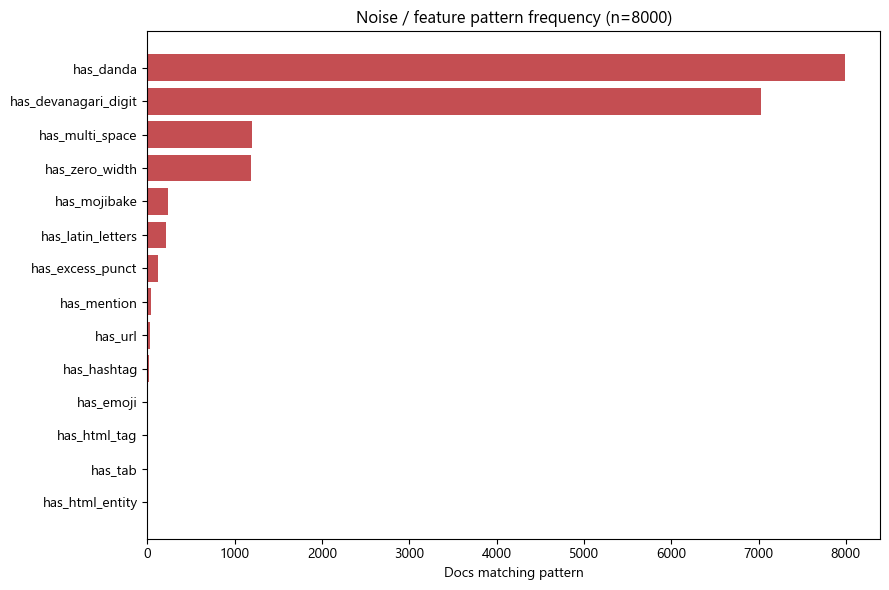

In [5]:
# Noise pattern detection (regex diagnostics) - Nepali-aware.
# Each regex asks: how many docs have THIS problem / feature?
patterns = {
    "has_url":              r"https?://\S+|www\.\S+",
    "has_mention":          r"@\w+",
    "has_hashtag":          r"#\w+",
    "has_html_tag":         r"<[^>]+>",
    "has_html_entity":      r"&[a-zA-Z]+;|&#\d+;",
    "has_emoji":            r"[\U0001F300-\U0001FAFF☀-➿]",
    "has_excess_punct":     r"[!?]{2,}|\.{3,}|।{2,}",
    "has_multi_space":      r"  +",
    "has_tab":              r"\t",
    "has_mojibake":         r"[¥Â]|â€|Ã",
    "has_latin_letters":    r"[A-Za-z]",
    "has_devanagari_digit": r"[०-९]",
    "has_danda":            r"[।॥]",
    "has_zero_width":       r"[​‌‍﻿]",
}
txt = df["text"].fillna("")
counts = {}
for name, pat in patterns.items():
    m = txt.str.contains(pat, regex=True, na=False)
    df[name] = m
    counts[name] = int(m.sum())
    print(f"{name:22s}: {m.sum():5d} docs ({m.mean()*100:5.1f}%)")

cs = pd.Series(counts).sort_values()
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(cs.index, cs.values, color="#C44E52")
ax.set_xlabel("Docs matching pattern")
ax.set_title(f"Noise / feature pattern frequency (n={len(df)})")
plt.tight_layout(); plt.show()

### What characters are actually in the text?

**What it does:** groups **every character** by its Unicode "block" (script) — Devanagari
letters, Devanagari digits, whitespace, Latin, punctuation, etc. — and lists any leftover
"other" characters.

**Why we do it:** for Nepali, non-English characters are **normal**, so we can't just call
them "junk". Instead we categorize them, which makes the *real* hidden junk stand out.

**Output:** Devanagari letters dominate (~4.5M), and it reveals **30 stray characters**
(like `© « × 🌺 🙏` and even Arabic letters) that don't belong in Nepali news.

In [6]:
# Character-level inspection by Unicode block.
# For Nepali "non-ASCII" is the NORM, so we categorise characters by script.
def char_block(c):
    o = ord(c)
    if 0x0966 <= o <= 0x096F: return "Devanagari digit"
    if 0x0900 <= o <= 0x097F: return "Devanagari"
    if o < 0x80 and c.isalpha(): return "Latin (ASCII)"
    if o < 0x80 and c.isdigit(): return "ASCII digit"
    if c.isspace():              return "whitespace"
    if o < 0x80:                 return "ASCII punct/other"
    if 0x2000 <= o <= 0x206F:    return "general punctuation"
    return "other non-ASCII"

sample_text = "".join(df["text"].fillna("").head(3000).tolist())
block_counts = Counter(char_block(c) for c in sample_text)
for b, n in block_counts.most_common():
    print(f"{b:22s}: {n:9d}")

others = sorted({c for c in set(sample_text) if char_block(c) == "other non-ASCII"})
print(f"\nUnique 'other non-ASCII' characters ({len(others)}) - often the hidden junk:")
print("  " + " ".join(others[:60]))

Devanagari            :   4490871
whitespace            :    842845
Devanagari digit      :     51280
ASCII punct/other     :     34698
general punctuation   :     17013
Latin (ASCII)         :      3324
other non-ASCII       :       335
ASCII digit           :       118

Unique 'other non-ASCII' characters (30) - often the hidden junk:
  ¥ © « ­ ´ È × Ù ì ÷ ø Œ œ ˆ ا ب د ط ل ن و ي ⇒   ﻿ 🌺 🌻 😊 🙏


### Counting words (building the vocabulary)

**What it does:** splits text on spaces and counts how often each word appears.
Note: unlike English, we **do NOT lowercase** — Devanagari has no capital/small letters.
- **N** = total number of words, **|V|** = number of *unique* words
- **type–token ratio |V|/N** measures how varied the vocabulary is

**Why we do it:** to see how big and how sparse the vocabulary is.

**Output — the important finding:** about **60% of unique words are "singletons"** (they
appear only once). That is a huge, sparse vocabulary — exactly the problem that **subword
tokenization (BPE)** solves later.

Total tokens (N):        2,168,061
Vocabulary size (|V|):   196,470
Type-token ratio |V|/N:  0.0906


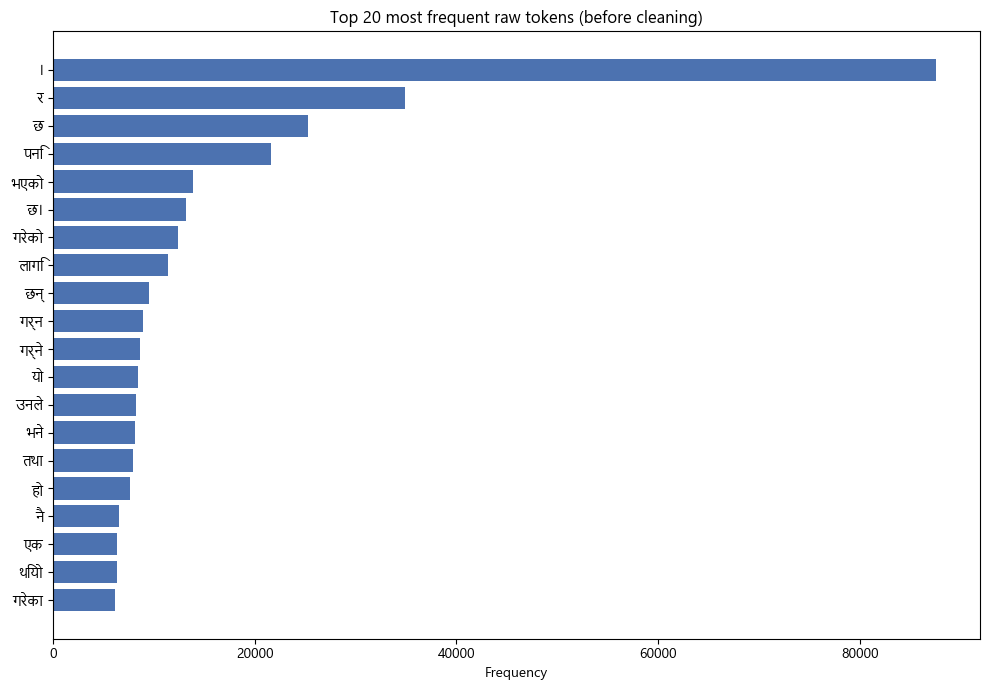


Singletons (appear exactly once): 118,301 (60.2% of vocab)
Sample singletons: ['लहान–१९', 'चूणामणि', 'हुनुभएका', 'श्रीपुर–३', 'पतिष्ठानमा', 'दाहसंकारका', 'क्यालिर्फोनिया–विश्वप्रसिद्ध', 'डेस्कटपमा', 'डेस्कटपमासमेत', 'परीक्षणकालागि', 'प्रयोगकर्तालेमात्र', 'विषेशत']


In [7]:
# Vocabulary & frequency analysis (naive whitespace tokenization).
# Devanagari has NO case, so - unlike English - we do NOT lowercase here.
def naive_tokenize(text):
    return str(text).split()

all_tokens = []
for t in df["text"].fillna(""):
    all_tokens.extend(naive_tokenize(t))

tok_counts   = Counter(all_tokens)
total_tokens = len(all_tokens)
vocab_size   = len(tok_counts)
print(f"Total tokens (N):        {total_tokens:,}")
print(f"Vocabulary size (|V|):   {vocab_size:,}")
print(f"Type-token ratio |V|/N:  {vocab_size/total_tokens:.4f}")

top = tok_counts.most_common(20)
labels, values = zip(*top)
fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(range(len(labels)), list(values)[::-1], color="#4C72B0")
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(list(labels)[::-1])
ax.set_title("Top 20 most frequent raw tokens (before cleaning)")
ax.set_xlabel("Frequency")
plt.tight_layout(); plt.show()

singletons = [w for w, c in tok_counts.items() if c == 1]
print(f"\nSingletons (appear exactly once): {len(singletons):,} "
      f"({len(singletons)/vocab_size*100:.1f}% of vocab)")
print("Sample singletons:", singletons[:12])

### Zipf's Law — *why subword tokenization exists*

**What it does:** plots each word's **frequency vs its rank** on a log–log scale.

**Why we do it:** it shows a few words are extremely common while a massive **"long tail"**
of words appears just once. This near-straight line is **Zipf's Law**.

**Take-away:** if we treat **whole words** as our unit, the vocabulary keeps growing and
stays sparse forever. That is the motivation for breaking words into **smaller reusable
pieces** (subwords) — the idea behind BPE.

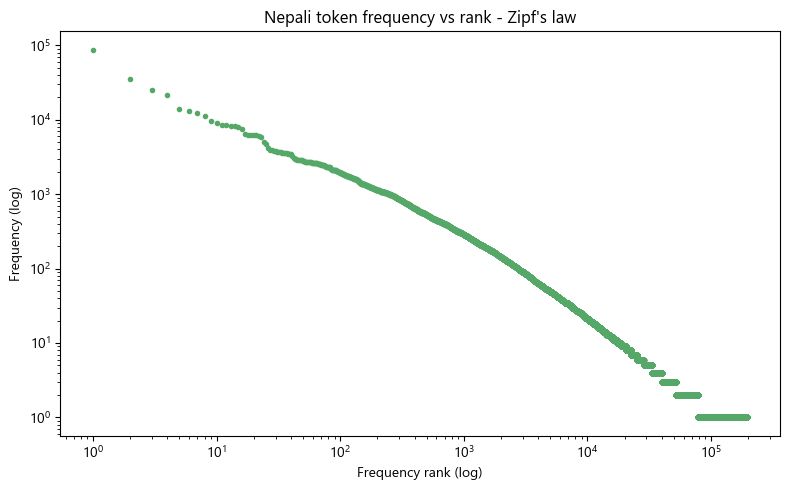

A few words appear very frequently; a long tail appears once. Treating whole words
as the unit => a huge, sparse vocabulary that never stops growing (Herdan/Heaps' law).


In [8]:
# Zipf's law: token frequency vs rank (log-log). This is WHY subword tokenization exists.
freqs = sorted(tok_counts.values(), reverse=True)
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(range(1, len(freqs) + 1), freqs, marker=".", linestyle="none", color="#55A868")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("Frequency rank (log)"); ax.set_ylabel("Frequency (log)")
ax.set_title("Nepali token frequency vs rank - Zipf's law")
plt.tight_layout(); plt.show()
print("A few words appear very frequently; a long tail appears once. Treating whole words")
print("as the unit => a huge, sparse vocabulary that never stops growing (Herdan/Heaps' law).")

### Unicode normalization (NFC)

**What it does:** the *same* Nepali word can be stored as **different byte sequences**
(composed vs decomposed forms) that look identical on screen. **NFC** normalization merges
these invisible duplicates. (English's version of this problem is `The` vs `the` — but
Devanagari has no case, so this Unicode issue takes its place.)

**Why we do it:** invisible duplicates would otherwise inflate the vocabulary and split
counts for the same word.

**Output:** in our clean-ish sample NFC collapsed **0** words, and lowercasing only merged
**52** Latin variants — small here, but we keep NFC because on other data it matters a lot.

In [9]:
# Normalization check - the Nepali analog of English "case inflation".
# Devanagari has no upper/lowercase, BUT the same word can be encoded with different
# Unicode byte sequences (composed vs decomposed, NFC vs NFD). NFC collapses these
# invisible duplicates.
raw_vocab   = set(t for text in df["text"].fillna("") for t in str(text).split())
nfc_vocab   = set(unicodedata.normalize("NFC", t) for t in raw_vocab)
lower_vocab = set(unicodedata.normalize("NFC", t).lower() for t in raw_vocab)  # .lower() only affects Latin
print(f"Raw vocab:               {len(raw_vocab):,}")
print(f"After NFC normalization: {len(nfc_vocab):,}  (collapsed {len(raw_vocab)-len(nfc_vocab)})")
print(f"After NFC + lowercase:   {len(lower_vocab):,}  (further -{len(nfc_vocab)-len(lower_vocab)} Latin variants)")

Raw vocab:               196,470
After NFC normalization: 196,470  (collapsed 0)
After NFC + lowercase:   196,418  (further -52 Latin variants)


### Turning findings into a to-do list

**What it does:** builds a small table pairing **each measured problem** with **the action**
we'll take (e.g. *"238 docs with mojibake → Fix encoding"*).

**Why we do it:** this is the bridge from **diagnosis** to **cleaning** — every cleaning
step below traces back to a number we actually measured.

In [10]:
# Finding -> Action summary
summary = pd.DataFrame([
    {"Finding": f"{n_null} null / {n_empty} empty rows",               "Action": "Drop null/empty"},
    {"Finding": f"{n_dup} exact duplicate texts",                      "Action": "Deduplicate (after cleaning)"},
    {"Finding": f"{counts['has_html_tag']} docs with HTML tags",       "Action": "Strip HTML"},
    {"Finding": f"{counts['has_url']} docs with URLs",                 "Action": "Remove URLs"},
    {"Finding": f"{counts['has_mojibake']} docs with mojibake",        "Action": "Fix encoding"},
    {"Finding": f"{counts['has_emoji']} docs with emoji",              "Action": "Strip emoji"},
    {"Finding": f"{counts['has_zero_width']} docs with zero-width chars","Action": "Remove ZWJ/ZWNJ/BOM"},
    {"Finding": f"{counts['has_multi_space']+counts['has_tab']} docs irregular whitespace","Action": "Normalize whitespace"},
    {"Finding": f"{counts['has_latin_letters']} docs mix Latin/English","Action": "Decide: keep or drop Latin"},
    {"Finding": f"vocab -{len(raw_vocab)-len(nfc_vocab)} on NFC",      "Action": "Unicode NFC normalize"},
    {"Finding": f"{len(singletons)} singletons ({len(singletons)/vocab_size*100:.0f}% of vocab)","Action": "Motivates subword (BPE)"},
])
print(summary.to_string(index=False))

                         Finding                       Action
           2 null / 2 empty rows              Drop null/empty
         1 exact duplicate texts Deduplicate (after cleaning)
           1 docs with HTML tags                   Strip HTML
               24 docs with URLs                  Remove URLs
          238 docs with mojibake                 Fix encoding
              10 docs with emoji                  Strip emoji
 1186 docs with zero-width chars          Remove ZWJ/ZWNJ/BOM
  1196 docs irregular whitespace         Normalize whitespace
      213 docs mix Latin/English   Decide: keep or drop Latin
                 vocab -0 on NFC        Unicode NFC normalize
118301 singletons (60% of vocab)      Motivates subword (BPE)


### The cleaning plan — *order matters*

**What it does:** lists the **10 cleaning steps in order**.

**Why the order matters:** cleaning (steps 1–8) happens **before** removing duplicates
(step 10). Two articles that look *different* when raw (say, one has a tracking URL and one
doesn't) can become **identical after cleaning** — and those are exactly the duplicates we
want to catch. Dedup first would miss them.

In [11]:
# Ordered cleaning blueprint (plan only - implemented in the next section)
blueprint = [
    {"step": 1,  "action": "Fix encoding (mojibake)"},
    {"step": 2,  "action": "Remove HTML tags + entities"},
    {"step": 3,  "action": "Remove URLs"},
    {"step": 4,  "action": "Remove @mentions / #hashtags"},
    {"step": 5,  "action": "Strip emoji"},
    {"step": 6,  "action": "Remove zero-width chars (ZWJ/ZWNJ/BOM)"},
    {"step": 7,  "action": "Unicode NFC normalization"},
    {"step": 8,  "action": "Normalize whitespace"},
    {"step": 9,  "action": "Drop empty rows"},
    {"step": 10, "action": "Deduplicate (AFTER cleaning reveals new dups)"},
]
print(pd.DataFrame(blueprint).to_string(index=False))
print("\nOrder matters: steps 1-8 run BEFORE dedup (step 10). Two docs that look different")
print("raw (one with a tracking URL, one without) can become identical after cleaning -")
print("those are exactly the duplicates worth catching.")

 step                                        action
    1                       Fix encoding (mojibake)
    2                   Remove HTML tags + entities
    3                                   Remove URLs
    4                  Remove @mentions / #hashtags
    5                                   Strip emoji
    6        Remove zero-width chars (ZWJ/ZWNJ/BOM)
    7                     Unicode NFC normalization
    8                          Normalize whitespace
    9                               Drop empty rows
   10 Deduplicate (AFTER cleaning reveals new dups)

Order matters: steps 1-8 run BEFORE dedup (step 10). Two docs that look different
raw (one with a tracking URL, one without) can become identical after cleaning -
those are exactly the duplicates worth catching.


## 3. Cleaning pipeline (implementation)

We now execute the blueprint in order and show a **before → after** comparison plus
the vocabulary reduction, so the effect of cleaning is *measured*, not assumed.

Note the Nepali-specific steps the English reference did not need: removing
**zero-width joiners** (ZWJ/ZWNJ, common in Devanagari typing) and **Unicode NFC
normalization**. We keep the **danda `।`** (Nepali full stop) — it is real
punctuation we will use for sentence segmentation later.

### Step 3 — Build the cleaner (one function per problem)

**What it does:** defines a small function for each fix — `fix_encoding` (mojibake),
`remove_html`, `remove_urls`, `remove_mentions_hashtags`, `strip_emoji`,
`remove_zero_width`, `nfc` (normalize), `normalize_whitespace` — and `clean_text` runs them
**in the planned order**. We apply it to every article to create a new `text_clean` column.

**Why one function per step:** it's easy to read, test, and reorder. **Important:** we
deliberately **keep the danda `।`** (Nepali full stop) because we need it to split sentences
later.

In [12]:
import html as html_lib

# Step 1 - mojibake fixes actually seen in Nepali scrapes (e.g. stray ¥, smart quotes)
MOJIBAKE_MAP = {
    "â€™": "'", "â€˜": "'", "â€œ": '"', "â€\x9d": '"',
    "â€“": "-", "â€”": "-", "â€¦": "...",
    "¥": "", "Â": "",
}
def fix_encoding(text):
    for bad, good in MOJIBAKE_MAP.items():
        text = text.replace(bad, good)
    return text

def remove_html(text):
    text = re.sub(r"<[^>]+>", " ", text)
    return html_lib.unescape(text)

def remove_urls(text):
    return re.sub(r"https?://\S+|www\.\S+", " ", text)

def remove_mentions_hashtags(text):
    return re.sub(r"[@#]\w+", " ", text)

def strip_emoji(text):
    return re.sub(r"[\U0001F300-\U0001FAFF☀-➿]", " ", text)

def remove_zero_width(text):
    return re.sub(r"[​‌‍﻿]", "", text)

def nfc(text):
    return unicodedata.normalize("NFC", text)

def normalize_whitespace(text):
    text = text.replace("\t", " ").replace("\n", " ")
    return re.sub(r" +", " ", text).strip()

def clean_text(text):
    text = str(text)
    text = fix_encoding(text)
    text = remove_html(text)
    text = remove_urls(text)
    text = remove_mentions_hashtags(text)
    text = strip_emoji(text)
    text = remove_zero_width(text)
    text = nfc(text)
    text = normalize_whitespace(text)
    return text

df["text_clean"] = df["text"].fillna("").apply(clean_text)

### Drop empties + duplicates, and *measure* the effect

**What it does:** drops empty rows, then duplicate rows, and prints **before → after**
counts plus how much the vocabulary shrank. It also shows a few **before/after** text
examples.

**Why we do it:** we **prove** cleaning worked with numbers instead of assuming it.

**Output:** rows go 8000 → 7998 (2 empties removed), and the vocabulary drops from
~196,470 → ~195,989. The before/after examples show extra spaces collapsed into one.

In [13]:
# Apply steps 9-10 (drop empty, then deduplicate) and measure the effect
n_before      = len(df)
df_clean      = df[df["text_clean"].str.strip() != ""].copy()
n_after_empty = len(df_clean)
df_clean      = df_clean.drop_duplicates(subset="text_clean").copy()
n_after_dedup = len(df_clean)

print(f"Rows before:           {n_before}")
print(f"After dropping empty:  {n_after_empty}  (-{n_before-n_after_empty})")
print(f"After deduplication:   {n_after_dedup}  (-{n_after_empty-n_after_dedup})")

raw_v   = set(t for x in df["text"].fillna("") for t in str(x).split())
clean_v = set(t for x in df_clean["text_clean"] for t in x.split())
print(f"\nVocabulary  raw: {len(raw_v):,}  ->  clean: {len(clean_v):,}  "
      f"(-{len(raw_v)-len(clean_v)}, {(len(raw_v)-len(clean_v))/len(raw_v)*100:.1f}%)")

tmp = df.copy()
tmp["diff"] = tmp["text"].fillna("").str.len() - tmp["text_clean"].str.len()
print("\nBEFORE -> AFTER (largest length reductions):")
for _, r in tmp.nlargest(3, "diff")[["text", "text_clean"]].iterrows():
    print("\nBEFORE:", str(r["text"])[:150])
    print("AFTER :", str(r["text_clean"])[:150])

Rows before:           8000
After dropping empty:  7998  (-2)
After deduplication:   7998  (-0)



Vocabulary  raw: 196,470  ->  clean: 195,989  (-481, 0.2%)

BEFORE -> AFTER (largest length reductions):

BEFORE: बाबु, तिम्रो कविताले मेरो पुरिएको घर उप्काउँछ त ?   एकजना वयोवृद्ध बाले आशाको घुयेंत्रो फाल्नुभो कवितिर   कविको बोली बन्द भो   चुरिफुरी गलेर निमन भो ।
AFTER : बाबु, तिम्रो कविताले मेरो पुरिएको घर उप्काउँछ त ? एकजना वयोवृद्ध बाले आशाको घुयेंत्रो फाल्नुभो कवितिर कविको बोली बन्द भो चुरिफुरी गलेर निमन भो । बाले 

BEFORE: ३१ साउन, काठमाडौं । विश्वप्रसिद्ध चिनियाँ अटो निर्माता कम्पनी ‘च्याङ्गन’अब छिट्टै नेपाली बजारमा आउने भएको छ। औपचारिक रुपमै नेपालका लागि अफिसियल वेबसाई
AFTER : ३१ साउन, काठमाडौं । विश्वप्रसिद्ध चिनियाँ अटो निर्माता कम्पनी ‘च्याङ्गन’अब छिट्टै नेपाली बजारमा आउने भएको छ। औपचारिक रुपमै नेपालका लागि अफिसियल वेबसाई

BEFORE: यस चलचित्र ३१ जनवरीमा रिलिज हुनेछ। चलचित्रमा सैफको जोडीको रुपमा तबु देखिने भएकी छिन्। चलचित्रको पोस्टर सार्वजनिक भएपछि यतिबेला पोस्टरको चर्चा सुरुवात 
AFTER : यस चलचित्र ३१ जनवरीमा रिलिज हुनेछ। चलचित्रमा सैफको जोडीको रुपमा तबु देखिने भएकी छिन्। चल

## 4. Tokenization

**Tokenization** is the first stage of NLP: splitting running text into tokens.
The reference notebook makes a key point — *"word" is not a clean concept* — and it
is even messier for Nepali:

- **No case.** `They`/`they` is an English problem; Devanagari has no capitals.
- **Sentence boundary is `।` (danda)**, not `.`.
- **Agglutinative / suffix-rich morphology.** One written word packs several
  morphemes: `विद्यार्थीहरूलाई` = `विद्यार्थी` (student) + `हरू` (plural) + `लाई`
  (dative "to"). Common bound morphemes: `हरू` (plural), `को/का/की` (genitive),
  `ले` (ergative), `मा` (locative), `लाई` (dative).
- **Vocabulary grows without bound** (Herdan's Law: |V| = k·N^β, 0<β<1), and Nepali's
  rich suffixation makes it grow *faster* than English — every noun spawns dozens of
  inflected surface forms. This is the core motivation for **subword tokenization**.

We cover four levels, matching the reference: **Unicode/UTF-8 → regex → rule-based → BPE**.

### Tokenization Level 1 — Unicode & UTF-8

**What it does:** looks at how Nepali characters are stored inside the computer:
- every character has a **code point** (e.g. `क` = `U+0915`)
- in **UTF-8**, an English letter takes **1 byte** but each Devanagari character takes **3 bytes**

**Why it matters:** a Nepali document uses about **3× more bytes** than an English one of
the same character count. This affects memory and, later, how tokenizers measure length.
We also show simple **script detection** (counting Devanagari vs Latin characters).

In [14]:
# 4.1 Unicode & UTF-8 with REAL Nepali characters from our data
print("=== Code points ===")
for ch in ["क", "न", "म", "ा", "्", "०", "।"]:
    print(f"  {ch:3s}  U+{ord(ch):04X}   {unicodedata.name(ch, '?')}")

print("\n=== UTF-8 byte sizes ===")
for ch, script in [("a","ASCII"), ("क","Devanagari"), ("।","Devanagari danda"), ("😀","Emoji")]:
    print(f"  {ch:3s}  {script:18s} {len(ch.encode('utf-8'))} byte(s)")

print("\n=== A real Nepali document: characters vs UTF-8 bytes ===")
doc = df_clean["text_clean"].iloc[0]
enc = doc.encode("utf-8")
print(f"Characters (code points): {len(doc):,}")
print(f"UTF-8 bytes:              {len(enc):,}")
print(f"Avg bytes/char:           {len(enc)/len(doc):.2f}  (Devanagari = 3 bytes/char in UTF-8)")
print(f"UTF-32 would be:          {len(doc.encode('utf-32-le')):,} bytes "
      f"({len(doc.encode('utf-32-le'))/len(enc):.1f}x larger)")
print("First 120 chars:", doc[:120])

print("\n=== Script detection by Unicode range ===")
def detect_scripts(text):
    dev = sum(1 for c in text if "ऀ" <= c <= "ॿ")
    lat = sum(1 for c in text if c < "" and c.isalpha())
    return dev, lat
for s in ["नमस्ते, यो नेपाली पाठ हो।", "Mixed नेपाली and English", "Hello world"]:
    d, l = detect_scripts(s)
    print(f"  dev={d:3d} lat={l:3d}  | {s}")

=== Code points ===
  क    U+0915   DEVANAGARI LETTER KA
  न    U+0928   DEVANAGARI LETTER NA
  म    U+092E   DEVANAGARI LETTER MA
  ा    U+093E   DEVANAGARI VOWEL SIGN AA
  ्    U+094D   DEVANAGARI SIGN VIRAMA
  ०    U+0966   DEVANAGARI DIGIT ZERO
  ।    U+0964   DEVANAGARI DANDA

=== UTF-8 byte sizes ===
  a    ASCII              1 byte(s)
  क    Devanagari         3 byte(s)
  ।    Devanagari danda   3 byte(s)
  😀    Emoji              4 byte(s)

=== A real Nepali document: characters vs UTF-8 bytes ===
Characters (code points): 1,006
UTF-8 bytes:              2,690
Avg bytes/char:           2.67  (Devanagari = 3 bytes/char in UTF-8)
UTF-32 would be:          4,024 bytes (1.5x larger)
First 120 chars: धरान, माघ ७ गते । धरानस्थित बिपी कोइराला स्वास्थ्य विज्ञान प्रतिष्ठानमा पछिल्लो २४ घण्टामा कोरोना सङ्क्रमणबाट तीन जनाको 

=== Script detection by Unicode range ===
  dev= 20 lat=  0  | नमस्ते, यो नेपाली पाठ हो।
  dev=  6 lat= 15  | Mixed नेपाली and English
  dev=  0 lat= 10  | Hello wor

### Tokenization Level 2 — Regex tools for Nepali

**What it does:** three practical regex jobs:
1. **(a)** convert Devanagari digits `०१२` → `0 1 2`
2. **(b)** split text into **sentences on the danda `।`/`॥`** (not the English period)
3. **(c)** separate **Devanagari** word-chunks from **Latin** word-chunks

**Why we do it:** Nepali needs **different rules** than English — different digit symbols
and a different sentence-ending mark. Reusing English regex here would fail.

In [15]:
# 4.2 Regular expressions for Nepali NLP
doc = df_clean["text_clean"].iloc[0]

# (a) Devanagari digits -> ASCII digits
dev2ascii = {d: str(i) for i, d in enumerate("०१२३४५६७८९")}
print("Devanagari digits found:", re.findall(r"[०-९]+", doc)[:10])
converted = re.sub(r"[०-९]", lambda m: dev2ascii[m.group()], doc)
print("After digit conversion (sample):", converted[:80])

# (b) Sentence split on danda ।  (Nepali's full stop)
sents = [s.strip() for s in re.split(r"[।॥]", doc) if s.strip()]
print(f"\nSentences (split on danda): {len(sents)}")
print("First sentence:", (sents[0][:100] if sents else ""))

# (c) Devanagari words vs Latin words
dev_words = re.findall(r"[ऀ-ॿ]+", doc)
lat_words = re.findall(r"[A-Za-z]+", doc)
print(f"\nDevanagari word-chunks: {len(dev_words)}  e.g. {dev_words[:8]}")
print(f"Latin word-chunks:      {len(lat_words)}  e.g. {lat_words[:8]}")

Devanagari digits found: ['७', '२४', '६', '१९', '६२', '१', '८०', '२९', '८०', '११']
After digit conversion (sample): धरान, माघ 7 गते । धरानस्थित बिपी कोइराला स्वास्थ्य विज्ञान प्रतिष्ठानमा पछिल्लो 

Sentences (split on danda): 11
First sentence: धरान, माघ ७ गते

Devanagari word-chunks: 165  e.g. ['धरान', 'माघ', '७', 'गते', '।', 'धरानस्थित', 'बिपी', 'कोइराला']
Latin word-chunks:      0  e.g. []


### Tokenization Level 3 — Whitespace vs rule-based

**What it does:** compares two ways to split text into tokens:
- **Whitespace:** just split on spaces → `धरान,` keeps the comma stuck to the word.
- **Rule-based regex:** treats words, numbers, and each punctuation mark / danda as its own
  token → `धरान` and `,` come out separate.

**Why we do it:** punctuation stuck to a word creates **fake unique tokens** (`धरान` and
`धरान,` counted as two different words). Rule-based tokenization gives cleaner units.

In [16]:
# 4.3 Whitespace vs rule-based (regex) tokenization on Nepali
sample_sent = df_clean["text_clean"].iloc[0][:120]
print("Sample:", sample_sent, "\n")

ws = sample_sent.split()
print(f"Whitespace tokens ({len(ws)}): {ws[:20]}")

# Rule-based: Devanagari words, Latin words, numbers, and each danda/punct as its own token
TOKEN_RE = re.compile(r"[ऀ-ॿ]+|[A-Za-z]+|[०-९]+|\d+|[।॥,.!?;:]")
rb = TOKEN_RE.findall(sample_sent)
print(f"\nRule-based tokens ({len(rb)}): {rb[:24]}")
print("\nNote: the rule-based tokenizer splits the danda '।' off as its own token;")
print("whitespace tokenization leaves it stuck to the previous word.")

Sample: धरान, माघ ७ गते । धरानस्थित बिपी कोइराला स्वास्थ्य विज्ञान प्रतिष्ठानमा पछिल्लो २४ घण्टामा कोरोना सङ्क्रमणबाट तीन जनाको  

Whitespace tokens (18): ['धरान,', 'माघ', '७', 'गते', '।', 'धरानस्थित', 'बिपी', 'कोइराला', 'स्वास्थ्य', 'विज्ञान', 'प्रतिष्ठानमा', 'पछिल्लो', '२४', 'घण्टामा', 'कोरोना', 'सङ्क्रमणबाट', 'तीन', 'जनाको']

Rule-based tokens (19): ['धरान', ',', 'माघ', '७', 'गते', '।', 'धरानस्थित', 'बिपी', 'कोइराला', 'स्वास्थ्य', 'विज्ञान', 'प्रतिष्ठानमा', 'पछिल्लो', '२४', 'घण्टामा', 'कोरोना', 'सङ्क्रमणबाट', 'तीन', 'जनाको']

Note: the rule-based tokenizer splits the danda '।' off as its own token;
whitespace tokenization leaves it stuck to the previous word.


### 4.4 Subword tokenization — Byte-Pair Encoding (BPE)

Neither whole words (vocabulary explodes) nor characters (too small, sequences too
long) work as a universal unit. Modern NLP uses **subwords** learned from data.

**BPE** starts from individual characters and repeatedly **merges the most frequent
adjacent pair**, k times. Frequent words become single tokens; rare words split into
reusable pieces — so unknown words become *representable* instead of impossible.

We do this **twice**:
1. **From scratch** — the exact algorithm from the reference, so we can *watch* Nepali
   morphemes emerge as merges.
2. **A real trained tokenizer** (HuggingFace `tokenizers`) — then we demonstrate the
   **low-resource over-segmentation** problem the reference describes.

### Tokenization Level 4a — BPE *from scratch*

**What it does:** **BPE (Byte-Pair Encoding)** starts from single characters and repeatedly
**merges the most frequent neighbouring pair**. We run **50 merges** on Nepali words and
watch what it learns. (`</w>` marks the *end of a word*, so word-final suffixes show up as
merges.)

**Why it's the exciting part:** with **no grammar rules given**, BPE **automatically
discovers real Nepali suffixes** like `को`, `मा`, `ले`, `हरू` — purely from frequency. That
is the whole idea: let the data teach the pieces.

In [17]:
# 4.4a BPE FROM SCRATCH on Nepali words (the reference algorithm).
# '</w>' marks end-of-word, so word-final suffixes (को, मा, ...) show up as merges.
from collections import Counter as C

words = []
for t in df_clean["text_clean"].head(2000):
    words.extend(re.findall(r"[ऀ-ॿ]+", t))
word_freq = C(words)
print("Distinct Nepali words in mini-corpus:", len(word_freq))

corpus = {" ".join(list(w)) + " </w>": f for w, f in word_freq.items()}

def get_pair_stats(corpus):
    pairs = C()
    for word, freq in corpus.items():
        syms = word.split()
        for i in range(len(syms) - 1):
            pairs[(syms[i], syms[i + 1])] += freq
    return pairs

def merge_pair(pair, corpus):
    bigram = re.escape(" ".join(pair))
    pat = re.compile(r"(?<!\S)" + bigram + r"(?!\S)")
    return {pat.sub("".join(pair), w): f for w, f in corpus.items()}

NUM_MERGES = 50
merges = []
for i in range(NUM_MERGES):
    stats = get_pair_stats(corpus)
    if not stats:
        break
    best = stats.most_common(1)[0][0]
    corpus = merge_pair(best, corpus)
    merges.append(best)

print(f"\nLearned {len(merges)} merges. First 30 (most frequent adjacent pairs):")
for a, b in merges[:30]:
    print(f"  {a} + {b}  ->  {a + b}")
print("\nNotice merges like क+ो</w> -> को</w>, म+ा</w> -> मा</w>: BPE has *discovered*")
print("Nepali case suffixes with no linguistic rules given - purely from frequency.")

Distinct Nepali words in mini-corpus: 68052



Learned 50 merges. First 30 (most frequent adjacent pairs):
  ा + </w>  ->  ा</w>
  ो + </w>  ->  ो</w>
  क + ो</w>  ->  को</w>
  े + </w>  ->  े</w>
  ् + र  ->  ्र
  र + ्  ->  र्
  न + ्  ->  न्
  । + </w>  ->  ।</w>
  र + </w>  ->  र</w>
  ी + </w>  ->  ी</w>
  म + ा</w>  ->  मा</w>
  न + </w>  ->  न</w>
  ् + य  ->  ्य
  ल + े</w>  ->  ले</w>
  क + ा</w>  ->  का</w>
  ि + </w>  ->  ि</w>
  क + ा  ->  का
  ल + ा  ->  ला
  स + ्  ->  स्
  प + ्र  ->  प्र
  न + े</w>  ->  ने</w>
  त + </w>  ->  त</w>
  ै + </w>  ->  ै</w>
  क + </w>  ->  क</w>
  म + ा  ->  मा
  क + ्  ->  क्
  ा + ल  ->  ाल
  व + ि  ->  वि
  ग + र  ->  गर
  न + ि  ->  नि

Notice merges like क+ो</w> -> को</w>, म+ा</w> -> मा</w>: BPE has *discovered*
Nepali case suffixes with no linguistic rules given - purely from frequency.


### Tokenization Level 4b — a *real* trained BPE tokenizer

**What it does:** trains a proper BPE tokenizer (HuggingFace `tokenizers`) with a
**5,000-token vocabulary** on our Nepali sample, then tokenizes a test sentence.

**Key result:** `विद्यार्थीहरूले` splits into `विद्यार्थी` + `हरूले` — the plural `हरू` and
the `ले` suffix get **peeled off**, so subwords line up with real Nepali morphemes.
**"Fertility"** = tokens per word (1.33 here) — how much words get broken up. Low is good.

In [18]:
# 4.4b A REAL BPE tokenizer trained on our Nepali sample (HuggingFace `tokenizers`)
from tokenizers import Tokenizer
from tokenizers.models import BPE
from tokenizers.trainers import BpeTrainer
from tokenizers.pre_tokenizers import Whitespace

tok = Tokenizer(BPE(unk_token="[UNK]"))
tok.pre_tokenizer = Whitespace()
trainer = BpeTrainer(vocab_size=5000, special_tokens=["[UNK]"], min_frequency=2)

corpus_texts = df_clean["text_clean"].tolist()
tok.train_from_iterator(corpus_texts, trainer=trainer)
print("Trained BPE vocab size:", tok.get_vocab_size())

np_sentence = "नेपालका विद्यार्थीहरूले स्थानीय निर्वाचनमा भाग लिए।"
enc = tok.encode(np_sentence)
print("\nNepali sentence:", np_sentence)
print("BPE tokens:", enc.tokens)
print(f"words={len(np_sentence.split())}  tokens={len(enc.tokens)}  "
      f"fertility={len(enc.tokens)/len(np_sentence.split()):.2f} tokens/word")
print("\nSee how विद्यार्थीहरूले splits into विद्यार्थी + हरूले: the हरू plural + ले")
print("ergative suffixes are peeled off - subwords approximate Nepali morphemes.")

Trained BPE vocab size: 5000

Nepali sentence: नेपालका विद्यार्थीहरूले स्थानीय निर्वाचनमा भाग लिए।
BPE tokens: ['नेपालका', 'विद्यार्थी', 'हरूले', 'स्थानीय', 'निर्वाचनमा', 'भाग', 'लिए', '।']
words=6  tokens=8  fertility=1.33 tokens/word

See how विद्यार्थीहरूले splits into विद्यार्थी + हरूले: the हरू plural + ले
ergative suffixes are peeled off - subwords approximate Nepali morphemes.


### The low-resource / over-segmentation problem

**What it does:** feeds an **English** sentence into our **Nepali-trained** tokenizer.

**What happens:** it **shatters English into single letters** (fertility ~5.0) because it
never learned English words.

**Why this matters (the big lesson):** the reverse is the real-world problem — big
**English-trained** tokenizers (like GPT's) **over-segment Nepali** the same way. That makes
Nepali text more expensive and harder for large models to handle. **This is exactly why
training tokenizers on Nepali data matters** — the point of the whole notebook.

In [19]:
# 4.4c The multilingual / low-resource over-segmentation problem
en_sentence = "The students voted in the local election."
enc_en = tok.encode(en_sentence)
print("English through our NEPALI-trained BPE:")
print("  tokens:", enc_en.tokens)
print(f"  words={len(en_sentence.split())}  tokens={len(enc_en.tokens)}  "
      f"fertility={len(enc_en.tokens)/len(en_sentence.split()):.2f} tokens/word")

import random
random.seed(42)
docs = random.sample(corpus_texts, min(300, len(corpus_texts)))
tw = tt = 0
for d in docs:
    tw += len(d.split()); tt += len(tok.encode(d).tokens)
print(f"\nAvg fertility on Nepali docs: {tt/tw:.2f} subword-tokens per whitespace-word")

vocab = tok.get_vocab()
dev_subwords = sorted([w for w in vocab if re.fullmatch(r"[ऀ-ॿ]{2,}", w)],
                      key=lambda w: vocab[w])
print("\nSample Nepali subwords BPE learned (earliest / most frequent merges):")
print("  " + "  ".join(dev_subwords[:40]))
print("\n=> A tokenizer trained mostly on Nepali handles Nepali efficiently but shatters")
print("   English into many pieces. Symmetrically, English-trained GPT tokenizers")
print("   over-segment Nepali - the open low-resource problem from the reference.")

English through our NEPALI-trained BPE:
  tokens: ['T', 'h', 'e', 's', 't', 'u', 'd', 'e', 'n', 't', 's', 'v', 'o', 't', 'e', 'd', 'i', 'n', 't', 'h', 'e', 'l', 'o', 'c', 'a', 'l', 'e', 'l', 'e', 'c', 't', 'i', 'o', 'n', '.']
  words=7  tokens=35  fertility=5.00 tokens/word

Avg fertility on Nepali docs: 1.62 subword-tokens per whitespace-word



Sample Nepali subwords BPE learned (earliest / most frequent merges):


  को  मा  ्र  का  र्  न्  ले  ने  ्य  ला  स्  ार  नि  प्र  क्  ना  ता  गर  वि  ति  पा  रा  एको  यो  वा  सम  ेको  त्र  रु  गर्  ान  लाई  सा  हु  उन  बा  ्या  या  दे  क्ष

=> A tokenizer trained mostly on Nepali handles Nepali efficiently but shatters
   English into many pieces. Symmetrically, English-trained GPT tokenizers
   over-segment Nepali - the open low-resource problem from the reference.


## 5. Summary — what we did and learned

Mirroring the reference on **Nepali np20ng**, on a random sample:

1. **Diagnostics.** We *measured* structure, length outliers, noise patterns
   (Devanagari-aware regex), character blocks, vocabulary, singletons and **Zipf's
   law** — turning "it looks messy" into numbers that justify each cleaning step.
2. **Cleaning.** An ordered pipeline (encoding → HTML → URLs → mentions → emoji →
   zero-width → **NFC** → whitespace → drop-empty → dedup) with measured vocabulary
   reduction. Nepali needed extra steps English did not: ZWJ/ZWNJ removal and Unicode
   NFC normalization; and it keeps the **danda `।`**.
3. **Tokenization.** Unicode/UTF-8 (Devanagari = 3 bytes/char), regex tokenization,
   rule-based tokenization (danda as its own token), and **BPE trained on Nepali** —
   which automatically discovers Nepali suffixes (`हरू`, `को`, `ले`, `मा`) and
   exposes the low-resource **over-segmentation** problem.

**Key takeaway:** English NLP tooling does not transfer blindly to Nepali. Casing is
irrelevant, sentence boundaries and digits differ, morphology is far richer, and
Unicode normalization matters — which is exactly why **data-driven subword
tokenization (BPE)** is the right foundation for Nepali NLP.